In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../data/raw/online_retail_II.csv')

In [5]:
df = df.dropna(subset=['Customer ID'])

In [6]:
df.shape

(824364, 8)

In [7]:
null_df = df[df['Description'].isnull()]
null_df.head()
null_df.shape

(0, 8)

In [8]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [9]:
df.duplicated().sum()

26479

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

0

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 797885 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      797885 non-null  object 
 1   StockCode    797885 non-null  object 
 2   Description  797885 non-null  object 
 3   Quantity     797885 non-null  int64  
 4   InvoiceDate  797885 non-null  object 
 5   Price        797885 non-null  float64
 6   Customer ID  797885 non-null  float64
 7   Country      797885 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 54.8+ MB


In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [14]:
df['Customer ID'] = df['Customer ID'].astype(str)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 797885 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      797885 non-null  object        
 1   StockCode    797885 non-null  object        
 2   Description  797885 non-null  object        
 3   Quantity     797885 non-null  int64         
 4   InvoiceDate  797885 non-null  datetime64[ns]
 5   Price        797885 non-null  float64       
 6   Customer ID  797885 non-null  object        
 7   Country      797885 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 54.8+ MB


In [16]:
df['TotalPrice'] = df['Quantity'] * df['Price']
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDay'] = df['InvoiceDate'].dt.day


In [17]:
(df["Quantity"] < 0).sum()

18390

In [18]:
df[df["Quantity"] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,InvoiceYear,InvoiceMonth,InvoiceDay
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.40,2009,12,1
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,-9.90,2009,12,1
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,-17.00,2009,12,1
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,-12.60,2009,12,1
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.40,2009,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,-9.13,2011,12,9
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,-224.69,2011,12,9
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,-54.75,2011,12,9
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,-1.25,2011,12,9


In [19]:
df["Invoice"].astype(str).str.startswith("C").sum()

18390

<Axes: xlabel='Quantity', ylabel='Count'>

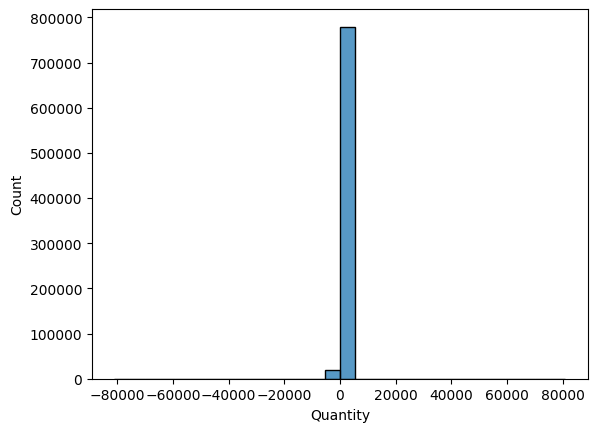

In [20]:
sns.histplot(df["Quantity"], bins=30)

<Axes: xlabel='Quantity'>

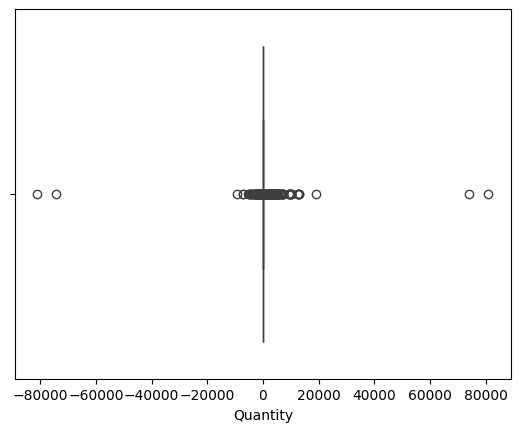

In [21]:
sns.boxplot(x=df["Quantity"])

<Axes: xlabel='Price'>

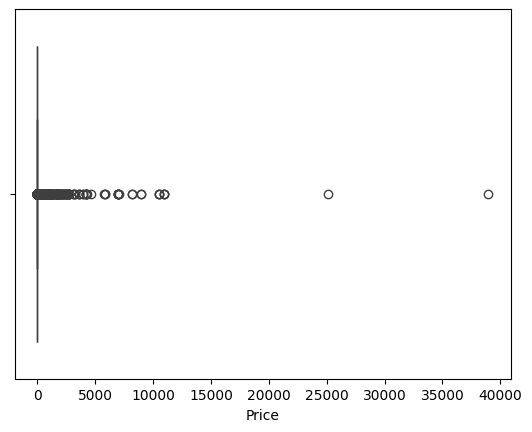

In [22]:
sns.boxplot(x=df["Price"])

In [23]:
df.describe()

,Quantity,InvoiceDate,Price,TotalPrice,InvoiceYear,InvoiceMonth,InvoiceDay
count,797885.000000,797885,797885.000000,797885.000000,797885.000000,797885.000000,797885.000000
mean,12.602980,2011-01-02 13:17:34.141160704,3.702732,20.416465,2010.431108,7.411434,15.387388
min,-80995.000000,2009-12-01 07:45:00,0.000000,-168469.600000,2009.000000,1.000000,1.000000
25%,2.000000,2010-07-02 09:47:00,1.250000,4.350000,2010.000000,5.000000,8.000000
50%,5.000000,2010-12-02 12:33:00,1.950000,11.700000,2010.000000,8.000000,15.000000
75%,12.000000,2011-07-31 15:50:00,3.750000,19.500000,2011.000000,10.000000,23.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,168469.600000,2011.000000,12.000000,31.000000
std,191.670371,NaN,71.392549,313.518824,0.568904,3.424495,8.658264


In [24]:
cleaned_df = df[df["Invoice"].astype(str).str.startswith("C") == False] 

In [25]:
(cleaned_df['Price'] < 0).sum()

0

In [26]:
cancelled_df = df[
    (df["Invoice"].astype(str).str.startswith("C")) |
    (df["Quantity"] < 0)
]

In [27]:
cleaned_df.shape, cancelled_df.shape

((779495, 12), (18390, 12))

In [28]:
cleaned_df.describe()

,Quantity,InvoiceDate,Price,TotalPrice,InvoiceYear,InvoiceMonth,InvoiceDay
count,779495.000000,779495,779495.000000,779495.000000,779495.000000,779495.000000,779495.000000
mean,13.507085,2011-01-03 01:46:36.061116416,3.218199,22.289821,2010.432050,7.417110,15.390820
min,1.000000,2009-12-01 07:45:00,0.000000,0.000000,2009.000000,1.000000,1.000000
25%,2.000000,2010-07-02 14:39:00,1.250000,4.950000,2010.000000,5.000000,8.000000
50%,6.000000,2010-12-02 14:09:00,1.950000,12.480000,2010.000000,8.000000,15.000000
75%,12.000000,2011-08-01 13:48:00,3.750000,19.800000,2011.000000,11.000000,23.000000
max,80995.000000,2011-12-09 12:50:00,10953.500000,168469.600000,2011.000000,12.000000,31.000000
std,146.540284,NaN,29.674823,227.416962,0.568394,3.422346,8.657937


In [29]:
cleaned_df[cleaned_df['Price'] == 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,InvoiceYear,InvoiceMonth,InvoiceDay
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom,0.0,2009,12,2
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom,0.0,2009,12,3
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom,0.0,2009,12,7
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom,0.0,2009,12,8
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom,0.0,2009,12,8
...,...,...,...,...,...,...,...,...,...,...,...,...
1004540,577129,22464,HANGING METAL HEART LANTERN,4,2011-11-17 19:52:00,0.0,15602.0,United Kingdom,0.0,2011,11,17
1005014,577168,M,Manual,1,2011-11-18 10:42:00,0.0,12603.0,Germany,0.0,2011,11,18
1006110,577314,23407,SET OF 2 TRAYS HOME SWEET HOME,2,2011-11-18 13:23:00,0.0,12444.0,Norway,0.0,2011,11,18
1011446,577696,M,Manual,1,2011-11-21 11:57:00,0.0,16406.0,United Kingdom,0.0,2011,11,21


In [30]:
cleaned_df = cleaned_df[cleaned_df['Price'] > 0]

In [31]:
cleaned_df[cleaned_df['Price'] == 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,InvoiceYear,InvoiceMonth,InvoiceDay


In [32]:
df["Invoice"].duplicated().sum()

753009

In [33]:
df["Invoice"].nunique()

44876

In [34]:
customer_frequency = (
    df.groupby("Customer ID")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
)

customer_frequency.head()

Customer ID
14911.0    510
12748.0    365
17841.0    289
15311.0    270
14606.0    259
Name: Invoice, dtype: int64

In [35]:
cleaned_df.shape

(779425, 12)

In [36]:
cleaned_df.to_csv('../data/processed/cleaned_retail_data.csv', index=False) 

In [37]:
cancelled_df.to_csv('../data/processed/cancelled_retail_data.csv', index=False) 

In [38]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice       779425 non-null  object        
 1   StockCode     779425 non-null  object        
 2   Description   779425 non-null  object        
 3   Quantity      779425 non-null  int64         
 4   InvoiceDate   779425 non-null  datetime64[ns]
 5   Price         779425 non-null  float64       
 6   Customer ID   779425 non-null  object        
 7   Country       779425 non-null  object        
 8   TotalPrice    779425 non-null  float64       
 9   InvoiceYear   779425 non-null  int32         
 10  InvoiceMonth  779425 non-null  int32         
 11  InvoiceDay    779425 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(1), object(5)
memory usage: 68.4+ MB


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 797885 entries, 0 to 1067370
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice       797885 non-null  object        
 1   StockCode     797885 non-null  object        
 2   Description   797885 non-null  object        
 3   Quantity      797885 non-null  int64         
 4   InvoiceDate   797885 non-null  datetime64[ns]
 5   Price         797885 non-null  float64       
 6   Customer ID   797885 non-null  object        
 7   Country       797885 non-null  object        
 8   TotalPrice    797885 non-null  float64       
 9   InvoiceYear   797885 non-null  int32         
 10  InvoiceMonth  797885 non-null  int32         
 11  InvoiceDay    797885 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(1), object(5)
memory usage: 70.0+ MB


In [40]:
cleaned_df['StockCode'].nunique()

4631

In [41]:
top_20_products = (
    cleaned_df.groupby(["StockCode", "Description"])
    .size()
    .reset_index(name="Frequency")
    .sort_values("Frequency", ascending=False)
    .head(20)
)

top_20_products

,StockCode,Description,Frequency
4751,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5016
1862,22423,REGENCY CAKESTAND 3 TIER,3335
4456,84879,ASSORTED COLOUR BIRD ORNAMENT,2692
4725,85099B,JUMBO BAG RED RETROSPOT,2641
3627,47566,PARTY BUNTING,2098
281,20727,LUNCH BAG BLACK SKULL.,2045
505,21034,REX CASH+CARRY JUMBO SHOPPER,1950
1810,22382,LUNCH BAG SPACEBOY DESIGN,1890
679,21232,STRAWBERRY CERAMIC TRINKET BOX,1859
1177,21754,HOME BUILDING BLOCK WORD,1852


In [42]:
letter_stockcodes = cleaned_df[
    cleaned_df["StockCode"].str.contains(r"[A-Za-z]", regex=True, na=False)
]

letter_stockcodes[["StockCode", "Description"]].drop_duplicates()

,StockCode,Description
1,79323P,PINK CHERRY LIGHTS
2,79323W,WHITE CHERRY LIGHTS
12,48173C,DOOR MAT BLACK FLOCK
23,35004B,SET OF 3 BLACK FLYING DUCKS
28,84596F,SMALL MARSHMALLOWS PINK BOWL
...,...,...
912110,90014B,GOLD M.O.P. ORBIT NECKLACE
949659,82001S,SILVER RECORD COVER FRAME
1008823,84206B,CAT WITH SUNGLASSES BLANK CARD
1030162,90014C,SILVER AND BLACK ORBIT NECKLACE
